<a href="https://colab.research.google.com/github/fareehaikram93/assignment1-intern/blob/main/work/notebooks/ranking_signal_datacontract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ranking Signal Data Contract — Content Grain

**Grain:** one row per `(client_hash_id, content_hash_id)`
**Population:** clients with `access_profile == 'gsc_and_ga4'` and ≥90 days of GSC + GA4 history; content with at least `MIN_DAYS_OBSERVED` days of non-null `gsc_avg_position` in the trailing 90-day window.

This notebook builds the contracted dataset, validates it against the contract, and writes a versioned output + machine-readable manifest.


## 0. Parameters

Pin everything the contract depends on here, so re-runs are reproducible and the assumptions are visible in one place.

In [ ]:
import datetime as dt

# --- Contract parameters ---
WINDOW_DAYS = 90                  # trailing window length for the ranking signal
MIN_HISTORY_DAYS = 90             # minimum client history required (GSC and GA4)
MIN_DAYS_OBSERVED = 30            # minimum days of GSC data required per content row
SAMPLE_SIZE = 100_000             # cap on output rows (None to disable)
RANDOM_STATE = 42

# Freeze the snapshot date so the window doesn't silently drift between runs.
# Set to None on first run to use the latest available report_date; then hard-code
# the printed value below for all subsequent reproducible runs.
SNAPSHOT_DATE = None  # e.g. dt.date(2026, 7, 5)

CONTRACT_VERSION = "1.0.0"


## 1. Connect to the warehouse

In [ ]:
import os, getpass

# CI and power users set HF_TOKEN in the environment; everyone else gets the safe prompt.
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

Paste your Hugging Face READ token (hf_...): ··········


In [ ]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':       f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':       f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_query_90d':    f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_query_90d            2,414,248 rows


## 2. Pin the snapshot window

Resolved once, then reused everywhere downstream — this is what makes the dataset reproducible rather than a rolling target.

In [ ]:
import pandas as pd

max_report_date_in_data = con.sql(f"SELECT MAX(report_date) FROM {TABLES['fact_daily']}").fetchone()[0]
max_report_date = pd.Timestamp(SNAPSHOT_DATE) if SNAPSHOT_DATE else pd.Timestamp(max_report_date_in_data)
start_date_90d = max_report_date - pd.Timedelta(days=WINDOW_DAYS)

print(f'Snapshot date (frozen):   {max_report_date.date()}')
print(f'Window start:             {start_date_90d.date()}')
print(f'Latest date in warehouse: {max_report_date_in_data}')

if SNAPSHOT_DATE is None:
    print('\n⚠️  SNAPSHOT_DATE is not pinned. Copy the date above into the Parameters '
          'cell and re-run for a reproducible contract.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Snapshot date (frozen):   2026-06-30
Window start:             2026-04-01
Latest date in warehouse: 2026-06-30

⚠️  SNAPSHOT_DATE is not pinned. Copy the date above into the Parameters cell and re-run for a reproducible contract.


## 3. Population — eligible clients

Clients with the right access profile and enough history in both GSC and GA4.

In [ ]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
""").df()

clients_filtered = clients[
    (clients['access_profile'] == 'gsc_and_ga4') &
    (clients['gsc_data_start'] <= max_report_date - pd.Timedelta(days=MIN_HISTORY_DAYS)) &
    (clients['ga4_data_start'] <= max_report_date - pd.Timedelta(days=MIN_HISTORY_DAYS))
]

print(f'Eligible clients: {len(clients_filtered)} / {len(clients)}')
clients_filtered.head()

Eligible clients: 39 / 104


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
5,client_08d2847f24cf89c1,gsc_and_ga4,2025-07-21,2026-02-19
7,client_0e1acc6cd57b0eba,gsc_and_ga4,2025-09-24,2026-02-19
8,client_0fa64a184f18a4a0,gsc_and_ga4,2026-02-19,2026-02-17
10,client_157ffe4d4a595515,gsc_and_ga4,2026-02-19,2026-03-09
13,client_1a730cb2640a1abf,gsc_and_ga4,2026-02-19,2026-03-05


## 4. Content dimension (static attributes)

One row per `(client_hash_id, content_hash_id)` — as-of the current snapshot, not historical.

In [ ]:
dim_content_filtered = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        search_volume,
        competition,
        competition_level,
        cpc,
        char_count,
        main_intent,
        keyword_char_count,
        keyword_token_count,
        url_char_count,
        backlinks,
        category_count,
        word_count,
        content_type,
        provider_used,
        model_used,
        content_created_date,
        content_updated_date
    FROM {TABLES['dim_content']}
    WHERE client_hash_id IN (SELECT client_hash_id FROM clients_filtered)
""").df()

print(f'Content rows for eligible clients: {len(dim_content_filtered)}')
dim_content_filtered.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content rows for eligible clients: 300772


,client_hash_id,content_hash_id,search_volume,competition,competition_level,cpc,char_count,main_intent,keyword_char_count,keyword_token_count,url_char_count,backlinks,category_count,word_count,content_type,provider_used,model_used,content_created_date,content_updated_date
0,client_2094c6eb080311d5,content_149355c8dfc3f8e1,0,0.0,LOW,0.0,28921,informational,32,6,122,0,0,4038,keyword article,google,gemini-2.5-flash,2026-01-22,2026-05-12
1,client_2094c6eb080311d5,content_1497d20f8498c13f,0,0.0,LOW,0.0,16953,informational,51,9,102,0,0,2490,keyword article,gemini-generate-content,gemini-3-flash-preview,2026-05-05,2026-05-20
2,client_2094c6eb080311d5,content_14a3d47ccd0d15dc,0,0.0,LOW,0.0,25450,informational,27,5,97,0,0,3864,keyword article,None,gemini-2.5-flash,2025-12-09,2026-05-12
3,client_2094c6eb080311d5,content_14a6f92117604fef,0,0.0,LOW,0.0,18112,informational,29,6,109,0,0,2867,keyword article,None,gemini-3-flash-preview,2025-12-11,2026-05-20
4,client_2094c6eb080311d5,content_14a86c63a214f648,0,0.0,LOW,0.0,19539,informational,29,5,101,0,0,2949,keyword article,None,gemini-2.5-flash,2025-12-09,2026-05-12


## 5. Ranking signal — aggregated to content grain

This is the key fix versus a naive join: `fact_daily` is aggregated to `(client_hash_id, content_hash_id)` **before** joining to `dim_content_filtered`, so static content attributes are never duplicated across days. `days_observed` travels with the row as a built-in quality signal.

In [ ]:
gsc_avg_position_data = con.sql(f"""
    SELECT
        fd.client_hash_id,
        fd.content_hash_id,
        AVG(LEAST(100, GREATEST(1, fd.gsc_avg_position)))   AS gsc_avg_position_90d,
        COUNT(*)                   AS days_observed
    FROM {TABLES['fact_daily']} AS fd
    JOIN clients_filtered AS cf ON fd.client_hash_id = cf.client_hash_id
    JOIN dim_content_filtered AS dcf
        ON fd.client_hash_id = dcf.client_hash_id
       AND fd.content_hash_id = dcf.content_hash_id
    WHERE fd.gsc_avg_position IS NOT NULL
      AND fd.report_date BETWEEN '{start_date_90d.isoformat()}' AND '{max_report_date.isoformat()}'
    GROUP BY fd.client_hash_id, fd.content_hash_id
    HAVING COUNT(*) >= {MIN_DAYS_OBSERVED}
""").df()

print(f'Content rows meeting MIN_DAYS_OBSERVED={MIN_DAYS_OBSERVED}: {len(gsc_avg_position_data)}')
gsc_avg_position_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content rows meeting MIN_DAYS_OBSERVED=30: 106063


,client_hash_id,content_hash_id,gsc_avg_position_90d,days_observed
0,client_2094c6eb080311d5,content_1497d20f8498c13f,29.015515,41
1,client_2094c6eb080311d5,content_14feb5514613e44d,9.888390,82
2,client_2094c6eb080311d5,content_15200126d986d645,8.624711,31
3,client_2094c6eb080311d5,content_15770c63daac443b,23.142976,86
4,client_2094c6eb080311d5,content_15caf3515edbfac3,8.998384,55


## 6. Merge to the contracted grain

In [ ]:
merged_gsc_content = pd.merge(
    gsc_avg_position_data,
    dim_content_filtered,
    on=['client_hash_id', 'content_hash_id'],
    how='inner'
)

print(f'Contracted dataset rows: {len(merged_gsc_content)}')
merged_gsc_content.head()

Contracted dataset rows: 106063


,client_hash_id,content_hash_id,gsc_avg_position_90d,days_observed,search_volume,competition,competition_level,cpc,char_count,main_intent,...,keyword_token_count,url_char_count,backlinks,category_count,word_count,content_type,provider_used,model_used,content_created_date,content_updated_date
0,client_2094c6eb080311d5,content_1497d20f8498c13f,29.015515,41,0,0.0,LOW,0.0,16953,informational,...,9,102,0,0,2490,keyword article,gemini-generate-content,gemini-3-flash-preview,2026-05-05,2026-05-20
1,client_2094c6eb080311d5,content_14feb5514613e44d,9.888390,82,10,0.3,LOW,0.4,20870,transactional,...,6,111,0,4,3282,keyword article,google,gemini-3-flash-preview,2026-03-24,2026-06-22
2,client_2094c6eb080311d5,content_15200126d986d645,8.624711,31,10,0.0,LOW,0.0,18772,commercial,...,6,103,0,4,2849,keyword article,google,gemini-3-flash-preview,2026-03-24,2026-05-20
3,client_2094c6eb080311d5,content_15770c63daac443b,23.142976,86,0,0.0,LOW,0.0,17300,informational,...,8,102,0,0,2694,keyword article,google,gemini-3-flash-preview,2026-02-04,2026-06-29
4,client_2094c6eb080311d5,content_15caf3515edbfac3,8.998384,55,0,0.0,LOW,0.0,21518,informational,...,5,105,0,0,3139,keyword article,google,gemini-3-flash-preview,2026-04-13,2026-05-20


## 7. Contract validation

These assertions encode the contract itself. If any of them fail, the dataset is broken and should not be published — fix upstream rather than relaxing the check.

In [ ]:
errors = []

# --- Primary key: uniqueness and non-null ---
pk_cols = ['client_hash_id', 'content_hash_id']
if merged_gsc_content[pk_cols].isnull().any().any():
    errors.append('Primary key columns contain nulls')

dupes = merged_gsc_content.duplicated(subset=pk_cols).sum()
if dupes != 0:
    errors.append(f'{dupes} duplicate grain keys (client_hash_id, content_hash_id)')

# --- Population membership ---
if not merged_gsc_content['client_hash_id'].isin(clients_filtered['client_hash_id']).all():
    errors.append('Rows present for clients outside the eligible population')

# --- Value ranges ---
if not merged_gsc_content['gsc_avg_position_90d'].between(1, 100).all():
    errors.append('gsc_avg_position_90d out of plausible [1, 100] range')

if (merged_gsc_content['days_observed'] < MIN_DAYS_OBSERVED).any():
    errors.append(f'Rows with days_observed below MIN_DAYS_OBSERVED={MIN_DAYS_OBSERVED}')

# --- Required (non-nullable) columns ---
required_non_null = ['gsc_avg_position_90d', 'days_observed']
for col in required_non_null:
    n_null = merged_gsc_content[col].isnull().sum()
    if n_null:
        errors.append(f'{col} has {n_null} nulls but is contracted as non-nullable')

if errors:
    raise AssertionError('Contract validation FAILED:\n- ' + '\n- '.join(errors))
else:
    print(f'✅ Contract validation passed — {len(merged_gsc_content)} rows, '
          f'{merged_gsc_content[pk_cols].drop_duplicates().shape[0]} unique keys.')

✅ Contract validation passed — 106063 rows, 106063 unique keys.


## 8. Column dictionary

Documents type, nullability, and source for every contracted column — kept in code so it can't silently drift from the actual dataframe.

In [ ]:
COLUMN_CONTRACT = {
    'client_hash_id':        {'type': 'string',   'nullable': False, 'source': 'dim_clients',  'role': 'primary_key'},
    'content_hash_id':       {'type': 'string',   'nullable': False, 'source': 'dim_content',  'role': 'primary_key'},
    'gsc_avg_position_90d':  {'type': 'float',    'nullable': False, 'source': 'AVG(fact_daily.gsc_avg_position) over trailing 90d', 'role': 'target'},
    'days_observed':         {'type': 'int',      'nullable': False, 'source': 'COUNT(*) over same window', 'role': 'quality_signal'},
    'search_volume':         {'type': 'Int64',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'competition':           {'type': 'float',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'competition_level':     {'type': 'category', 'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'cpc':                   {'type': 'float',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'char_count':             {'type': 'Int64',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'main_intent':            {'type': 'string',   'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'keyword_char_count':     {'type': 'float',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'keyword_token_count':    {'type': 'float',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'url_char_count':         {'type': 'float',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'backlinks':              {'type': 'Int64',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'category_count':         {'type': 'float',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'word_count':              {'type': 'Int64',    'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'content_type':            {'type': 'category', 'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'provider_used':           {'type': 'category', 'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'model_used':               {'type': 'string',   'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'content_created_date':     {'type': 'date',     'nullable': True,  'source': 'dim_content', 'role': 'feature'},
    'content_updated_date':     {'type': 'date',     'nullable': True,  'source': 'dim_content', 'role': 'feature'},
}

# Sanity check: dictionary and dataframe columns must match exactly.
missing_in_df = set(COLUMN_CONTRACT) - set(merged_gsc_content.columns)
missing_in_dict = set(merged_gsc_content.columns) - set(COLUMN_CONTRACT)
assert not missing_in_df, f'Columns documented but missing from dataframe: {missing_in_df}'
assert not missing_in_dict, f'Columns in dataframe but undocumented: {missing_in_dict}'

pd.DataFrame(COLUMN_CONTRACT).T

,type,nullable,source,role
client_hash_id,string,False,dim_clients,primary_key
content_hash_id,string,False,dim_content,primary_key
gsc_avg_position_90d,float,False,AVG(fact_daily.gsc_avg_position) over trailing...,target
days_observed,int,False,COUNT(*) over same window,quality_signal
search_volume,Int64,True,dim_content,feature
competition,float,True,dim_content,feature
competition_level,category,True,dim_content,feature
cpc,float,True,dim_content,feature
char_count,Int64,True,dim_content,feature
main_intent,string,True,dim_content,feature


## 9. Sample, version, and write outputs

The sampled/full dataset plus a machine-readable manifest capturing everything the contract depends on.

In [ ]:
if SAMPLE_SIZE and len(merged_gsc_content) > SAMPLE_SIZE:
    merged_gsc_content_sample = merged_gsc_content.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    merged_gsc_content_sample = merged_gsc_content.copy()

print(f'Output rows: {len(merged_gsc_content_sample)}')
merged_gsc_content_sample.head()

Output rows: 100000


,client_hash_id,content_hash_id,gsc_avg_position_90d,days_observed,search_volume,competition,competition_level,cpc,char_count,main_intent,...,keyword_token_count,url_char_count,backlinks,category_count,word_count,content_type,provider_used,model_used,content_created_date,content_updated_date
23025,client_73cda7b4e4f265ea,content_ef89ff748f7faed7,8.541545,91,0,0.00,LOW,0.00,19397,informational,...,5,83,0,0,2883,keyword article,google,gemini-3-flash-preview,2026-02-10,2026-05-20
3946,client_73cda7b4e4f265ea,content_36166ace2994c2d6,17.373375,64,90,0.86,HIGH,0.27,<NA>,transactional,...,6,91,<NA>,0,<NA>,keyword article,None,None,2025-03-03,2026-05-18
101270,client_e547b89c05043229,content_f6963771704e02f9,6.866495,91,10,0.02,LOW,0.00,17435,informational,...,8,114,<NA>,0,2715,keyword article,None,gemini-3-flash-preview,2025-02-07,2026-07-06
76417,client_73cda7b4e4f265ea,content_efe1c906f4d7d66d,3.219822,91,40,0.01,LOW,0.00,<NA>,informational,...,6,108,<NA>,0,<NA>,keyword article,None,None,2025-02-14,2026-05-18
58441,client_73cda7b4e4f265ea,content_4d5bc13d6cfd81a6,6.780990,91,20,0.00,LOW,0.00,<NA>,transactional,...,6,127,<NA>,0,<NA>,keyword article,None,None,2025-07-31,2026-07-01


In [ ]:
import json

run_ts = dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
dataset_filename = f'ranking_signal_content_grain_{run_ts}.csv'
manifest_filename = f'ranking_signal_content_grain_{run_ts}.manifest.json'

manifest = {
    'contract_version': CONTRACT_VERSION,
    'grain': ['client_hash_id', 'content_hash_id'],
    'generated_at_utc': run_ts,
    'snapshot_date': str(max_report_date.date()),
    'window': {
        'start': str(start_date_90d.date()),
        'end': str(max_report_date.date()),
        'days': WINDOW_DAYS,
    },
    'population_filters': {
        'access_profile': 'gsc_and_ga4',
        'min_history_days': MIN_HISTORY_DAYS,
        'min_days_observed': MIN_DAYS_OBSERVED,
    },
    'row_counts': {
        'eligible_clients': int(len(clients_filtered)),
        'contracted_rows_full': int(len(merged_gsc_content)),
        'contracted_rows_output': int(len(merged_gsc_content_sample)),
        'sample_size_cap': SAMPLE_SIZE,
        'random_state': RANDOM_STATE,
    },
    'columns': COLUMN_CONTRACT,
    'validation': 'passed',
}

merged_gsc_content_sample.to_csv(dataset_filename, index=False)
with open(manifest_filename, 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

print(f'Wrote {dataset_filename}')
print(f'Wrote {manifest_filename}')

/tmp/ipykernel_1556/1269546171.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_ts = dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


Wrote ranking_signal_content_grain_20260811T100648Z.csv
Wrote ranking_signal_content_grain_20260811T100648Z.manifest.json


## 10. (Optional) Exploratory checks

Only meaningful now that the grain is fixed and clean — one row per content, no day-level fan-out inflating the correlations.

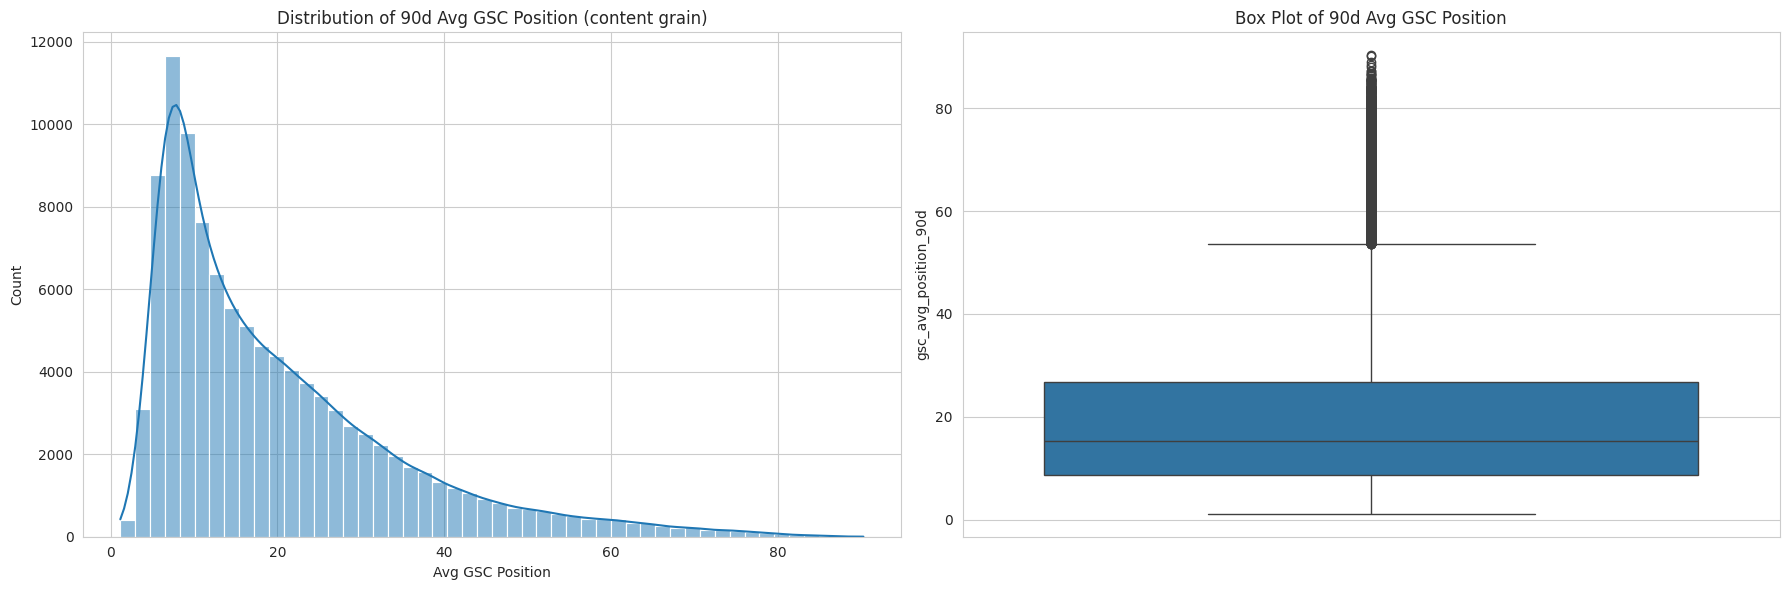

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(merged_gsc_content['gsc_avg_position_90d'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of 90d Avg GSC Position (content grain)')
axes[0].set_xlabel('Avg GSC Position')

sns.boxplot(y=merged_gsc_content['gsc_avg_position_90d'], ax=axes[1])
axes[1].set_title('Box Plot of 90d Avg GSC Position')

plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = merged_gsc_content.select_dtypes(include=['number']).columns
correlation_matrix = merged_gsc_content[numeric_cols].corr()

print("Correlation with gsc_avg_position_90d:")
correlation_matrix['gsc_avg_position_90d'].sort_values()

Correlation with gsc_avg_position_90d:


,gsc_avg_position_90d
days_observed,-0.082732
keyword_char_count,-0.076670
category_count,-0.051975
keyword_token_count,-0.005192
backlinks,0.000067
url_char_count,0.022199
char_count,0.028820
word_count,0.036459
cpc,0.048258
search_volume,0.051263
